In [2]:
#import libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Read the data
df = pd.read_csv("marketing_AB.csv")

In [4]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
#Check if we have duplicates with respect to user id
df.duplicated(subset='user id').sum()

np.int64(0)

In [6]:
#Drop Unwanted columns
df.drop(['Unnamed: 0','user id'],axis = 1,inplace= True)

In [7]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [10]:
#Check if categorial variables have appropriate number of levels
df_cat = df[['test group', 'converted','most ads day','most ads hour']]
df_cat.nunique()

test group        2
converted         2
most ads day      7
most ads hour    24
dtype: int64

In [15]:
#Check if categorial variables have appropriate levels
for i in df_cat:
    print(i.upper(),":",df[i].unique())

TEST GROUP : ['ad' 'psa']
CONVERTED : [False  True]
MOST ADS DAY : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
MOST ADS HOUR : [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


***Univariate Analysi***

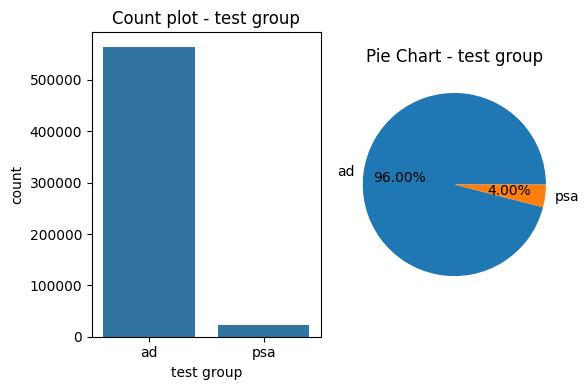

In [33]:
variable = 'test group'

plt.figure(figsize= (6,4))
#count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count plot - {variable}')

#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable]. value_counts()
plt.pie(counts, labels=counts.index, autopct ='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust Layout
plt.tight_layout()

#show the plots
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_33052\1811519211.py:15: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


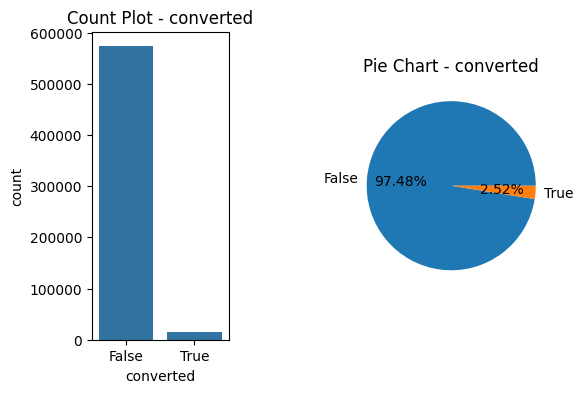

In [43]:
variable = 'converted'

plt.figure(figsize= (6,4))
#count plot
plt.subplot(1,3,1)
sns.countplot(x= variable, data= df_cat)
plt.title(f'Count Plot - {variable}')

#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct ='%0.2f%%')
plt.title(f'Pie Chart - {variable}')
#Adjust layout
plt.tight_layout()
#show the plot
plt.show()



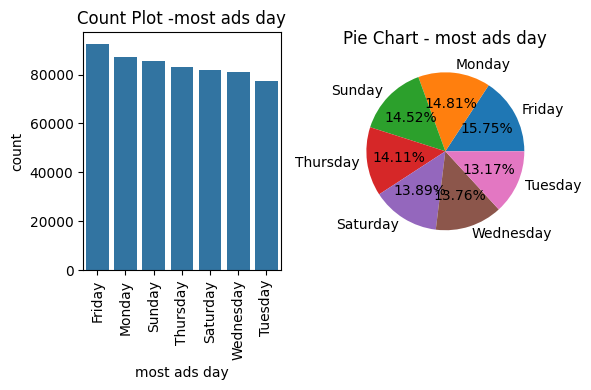

In [56]:
variable = 'most ads day'

plt.figure(figsize= (6,4))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat, order= df_cat[variable].value_counts().index)
plt.title(f'Count Plot -{variable}')
plt.xticks(rotation = 90)
#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts,labels = counts.index, autopct='%.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust the layout
plt.tight_layout()

#Show the plot
plt.show()

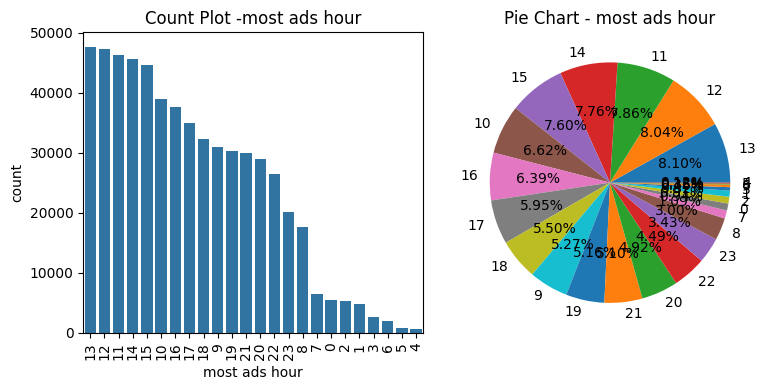

In [59]:
variable = 'most ads hour'

plt.figure(figsize= (8,4))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat, order= df_cat[variable].value_counts().index)
plt.title(f'Count Plot -{variable}')
plt.xticks(rotation = 90)
#pie chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts,labels = counts.index, autopct='%.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust the layout
plt.tight_layout()

#Show the plot
plt.show()

In [74]:
df['total ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

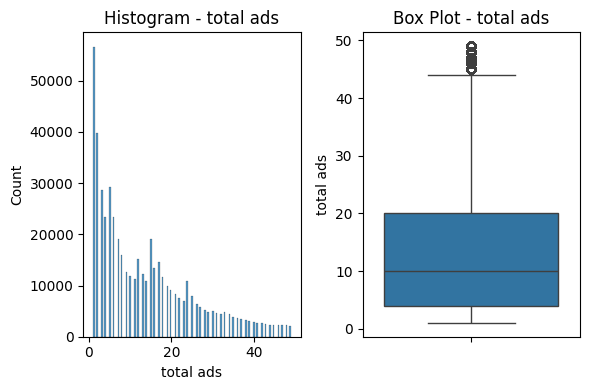

In [71]:
variable = 'total ads'

plt.figure(figsize =(6,4))
#Histogram
plt.subplot(1,2,1)
sns.histplot(x=variable,data = df[df[variable]< 50])
plt.title(f'Histogram - {variable}')

#Box Plot
plt.subplot(1,2,2)
sns.boxplot(y=variable,data = df[df[variable]< 50] )
plt.title(f'Box Plot - {variable}')

#Adjust Layout
plt.tight_layout()

#show the plot
plt.show()


***Bivariate Analysis***


In [75]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [76]:
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [78]:
ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'], normalize = 'index')
ct_conversion_test_group

converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


<Axes: xlabel='test group'>

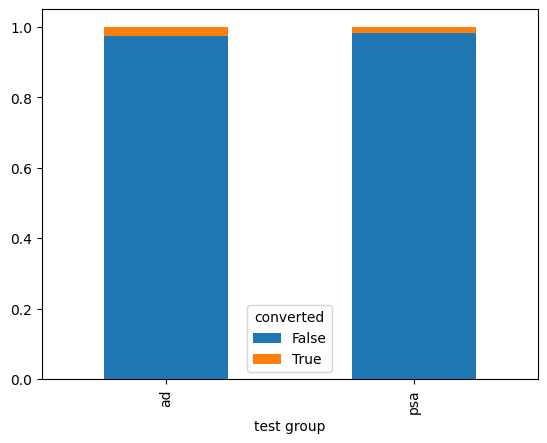

In [80]:
ct_conversion_test_group.plot.bar(stacked= True)

In [81]:
ct_conversion_day = pd.crosstab(df['most ads day'], df['converted'], normalize = 'index')
ct_conversion_day

converted,False,True
most ads day,,
Friday,0.977788,0.022212
Monday,0.967188,0.032812
Saturday,0.978949,0.021051
Sunday,0.975524,0.024476
Thursday,0.978429,0.021571
Tuesday,0.970160,0.029840
Wednesday,0.975058,0.024942


<Axes: xlabel='most ads day'>

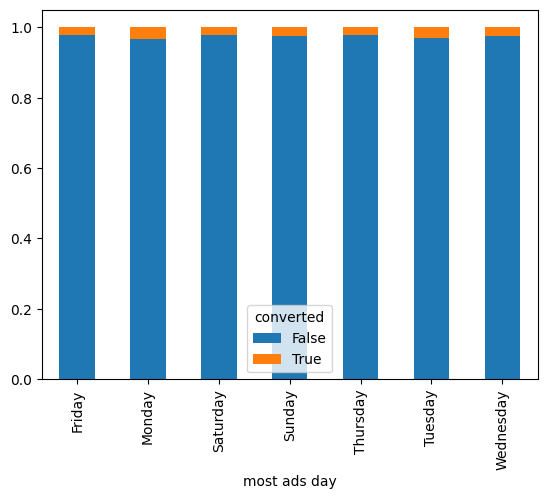

In [82]:
ct_conversion_day.plot.bar(stacked= True)

converted         False     True 
most ads hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


<Axes: xlabel='most ads hour'>

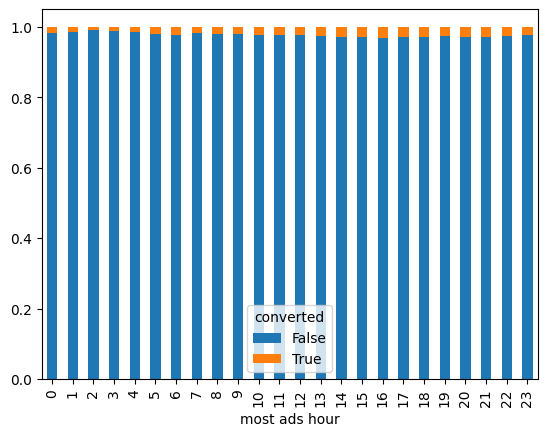

In [86]:
ct_conversion_hour = pd.crosstab(df['most ads hour'], df['converted'], normalize = 'index')
print(ct_conversion_hour.sort_values(by= True, ascending= False))
ct_conversion_hour.plot.bar(stacked= True)

<Axes: xlabel='converted', ylabel='total ads'>

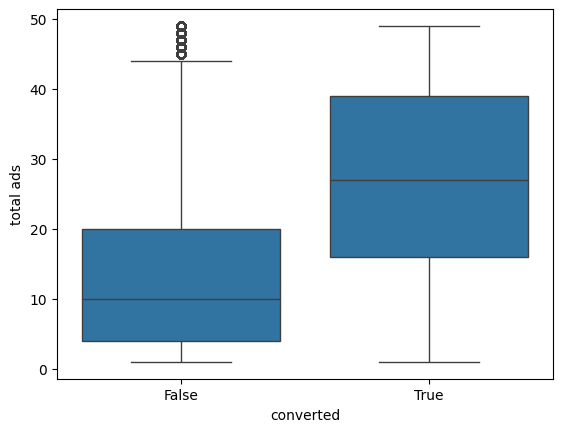

In [88]:
sns.boxplot(x='converted', y= 'total ads', data = df[df['total ads']< 50])

In [90]:
from scipy.stats import chi2_contingency
alpha = 0.05
for variable in df_cat.columns:
    if variable != 'converted':
        # Create a contingency table(cross-tabulation)
        contingency_table = pd.crosstab(df_cat[variable], df['converted'])

        #Perform Chi Sqaure Test
        chi2, p, _, _ =chi2_contingency(contingency_table)

        #Display the results
        print(f"\nChi-Squared test for {variable} vs converted")
        print(f"Chi-Squared value: {chi2}")
        print(f"p-value {p}")

        # CHeck for significance
        if p < alpha:
            print(f"The difference in conversion rates across {variable} is statistically significant")
        else:
            print(f"There is no significant difference in conersion rates across {variable}.")


Chi-Squared test for test group vs converted
Chi-Squared value: 54.005823883685245
p-value 1.9989623063390075e-13
The difference in conversion rates across test group is statistically significant

Chi-Squared test for most ads day vs converted
Chi-Squared value: 410.0478857936585
p-value 1.932184379244731e-85
The difference in conversion rates across most ads day is statistically significant

Chi-Squared test for most ads hour vs converted
Chi-Squared value: 430.76869230822086
p-value 8.027629823696771e-77
The difference in conversion rates across most ads hour is statistically significant


In [95]:
df[df['converted']== True]['total ads']

15           9
44         265
107       1328
121        323
135        246
          ... 
586343      14
586818      11
586990       8
587069       4
587665       3
Name: total ads, Length: 14843, dtype: int64

In [96]:
df[df['converted']== False]['total ads']

0         130
1          93
2          21
3         355
4         276
         ... 
588096      1
588097      1
588098      3
588099      1
588100      1
Name: total ads, Length: 573258, dtype: int64

In [94]:
from scipy.stats  import shapiro, levene, ttest_ind, mannwhitneyu

#Step 1: Check Assunptions
#Normality Assumption
shapiro_stat_true, shapiro_p_value_true =shapiro(df[df['converted']== True]['total ads'])
shapiro_stat_false, shapiro_p_value_false =shapiro(df[df['converted']== False]['total ads'])
print(f"Shapiro-Wilk test for normality (True group): p-value = {shapiro_p_value_true}")
print(f"Shapiro-Wilk test for normality (False group): p-value = {shapiro_p_value_false}")

#Equality of variances assumption
levene_stat, levene_p_value = levene(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
print(f"levene's test for equality of variences: p-value = {levene_p_value}")

Shapiro-Wilk test for normality (True group): p-value = 1.638680987007864e-98
Shapiro-Wilk test for normality (False group): p-value = 9.883049430733551e-204
levene's test for equality of variences: p-value = 0.0


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14843.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 573258.
  res = hypotest_fun_out(*samples, **kwds)


In [93]:
# Step2: Perform a Suitable Test
alpha = 0.05

if shapiro_p_value_true > alpha and shapiro_p_value_false> alpha and levene_p_value>alpa:
    #Assumption met --> Use t-test for means
    t_stat, t_p_value = ttest_ind(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
    print(f"Independent two-sample t-tet: p-value = {t_p_value}")

else:
     #Assumption  not met --> Use Mann-Whitney U test for medians
    u_stat, u_p_value = mannwhitneyu(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
    print(f"Mann-Whitney U test: p-value = {u_p_value}")

Mann-Whitney U test: p-value = 0.0
